In [85]:
import pandas as pd
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
data_set_1 = pd.read_csv('/Users/natalialogvinova/Desktop/DS-17 diploma/Raw_Jobs.csv', sep = ';')
print(data_set_1.shape)

(561989, 12)


In [87]:
data_set_1['key_skills'].values

array([nan, nan, nan, ...,
       'Желание работать и зарабатывать,Быстрообучаемый,Физическая выносливость',
       nan, nan], dtype=object)

In [88]:
def split_salary_column(df, salary_column, new_columns_prefix=''):
    """
    Разделяет столбец с зарплатой на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    salary_column (str): Название столбца с зарплатой
    new_columns_prefix (str): Префикс для новых столбцов
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами salary_from, salary_to, currency
    """
    
    # Создаем копию датафрейма
    result_df = data_set_1.copy()
    
    # Создаем новые столбцы
    result_df[f'{new_columns_prefix}salary_from'] = np.nan
    result_df[f'{new_columns_prefix}salary_to'] = np.nan
    result_df[f'{new_columns_prefix}currency'] = np.nan
    
    # Регулярные выражения для парсинга
    salary_pattern = r'от\s*(\d+[\d\s]*)\s*до\s*(\d+[\d\s]*)\s*([A-Z]{3})?|до\s*(\d+[\d\s]*)\s*([A-Z]{3})?|от\s*(\d+[\d\s]*)\s*([A-Z]{3})?|(\d+[\d\s]*)\s*([A-Z]{3})?'
    not_specified_pattern = r'з/п не указана'
    currency_pattern = r'([A-Z]{3})$'
    
    for idx, value in enumerate(result_df[salary_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        
        # Проверяем на "з/п не указана"
        if re.search(not_specified_pattern, value_str, re.IGNORECASE):
            result_df.at[idx, f'{new_columns_prefix}salary_from'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}salary_to'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}currency'] = np.nan
            continue
        
        # Ищем валюту в конце строки
        currency_match = re.search(currency_pattern, value_str)
        currency = currency_match.group(1) if currency_match else np.nan
        
        # Парсим зарплату
        salary_match = re.search(salary_pattern, value_str, re.IGNORECASE)
        
        if salary_match:
            groups = salary_match.groups()
            
            # Вариант: "от X до Y CUR"
            if groups[0] and groups[1]:
                salary_from = groups[0].replace(' ', '')
                salary_to = groups[1].replace(' ', '')
                currency_val = groups[2] if groups[2] else currency
            
            # Вариант: "до X CUR"
            elif groups[3]:
                salary_from = np.nan
                salary_to = groups[3].replace(' ', '')
                currency_val = groups[4] if groups[4] else currency
            
            # Вариант: "от X CUR"
            elif groups[5]:
                salary_from = groups[5].replace(' ', '')
                salary_to = np.nan
                currency_val = groups[6] if groups[6] else currency
            
            # Вариант: "X CUR"
            elif groups[7]:
                salary_from = groups[7].replace(' ', '')
                salary_to = np.nan
                currency_val = groups[8] if groups[8] else currency
            
            else:
                salary_from = np.nan
                salary_to = np.nan
                currency_val = np.nan
            
            # Записываем значения
            result_df.at[idx, f'{new_columns_prefix}salary_from'] = float(salary_from) if salary_from and salary_from != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}salary_to'] = float(salary_to) if salary_to and salary_to != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}currency'] = currency_val if currency_val and currency_val != 'nan' else np.nan
    
    return result_df

In [89]:
data_set_1 = split_salary_column(data_set_1, 'salary')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/689102006.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RUR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, f'{new_columns_prefix}currency'] = currency_val if currency_val and currency_val != 'nan' else np.nan


In [90]:
def split_experience_column(df, experience_column, new_columns_prefix=''):
    """
    Разделяет столбец с опытом работы на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    experience_column (str): Название столбца с опытом работы
    new_columns_prefix (str): Префикс для новых столбцов
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами experience_from, experience_to, no_experience
    """
    
    # Создаем копию датафрейма
    result_df = df.copy()
    
    # Создаем новые столбцы
    result_df[f'{new_columns_prefix}experience_from'] = np.nan
    result_df[f'{new_columns_prefix}experience_to'] = np.nan
    result_df[f'{new_columns_prefix}no_experience'] = False
    
    # Регулярные выражения для парсинга
    no_experience_pattern = r'(нет опыта|без опыта|без опыта работы|опыт не требуется|не требуется опыт)'
    
    experience_pattern = r'''
        от\s+(\d+)\s*(?:года|лет|год)\s+до\s+(\d+)\s*(?:года|лет|год)|  # от X года до Y года
        до\s+(\d+)\s*(?:года|лет|год)|                                  # до X года
        от\s+(\d+)\s*(?:года|лет|год)|                                  # от X года
        более\s+(\d+)\s*(?:года|лет|год)|                               # более X года
        (\d+)\s*(?:года|лет|год)                                        # X года
    '''
    
    for idx, value in enumerate(result_df[experience_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip().lower()
        
        # Проверяем на "нет опыта"
        if re.search(no_experience_pattern, value_str, re.IGNORECASE):
            result_df.at[idx, f'{new_columns_prefix}no_experience'] = True
            result_df.at[idx, f'{new_columns_prefix}experience_from'] = np.nan
            result_df.at[idx, f'{new_columns_prefix}experience_to'] = np.nan
            continue
        
        # Парсим опыт работы
        experience_match = re.search(experience_pattern, value_str, re.IGNORECASE | re.VERBOSE)
        
        if experience_match:
            groups = experience_match.groups()
            
            # Вариант: "от X года до Y года"
            if groups[0] and groups[1]:
                experience_from = groups[0]
                experience_to = groups[1]
            
            # Вариант: "до X года"
            elif groups[2]:
                experience_from = np.nan
                experience_to = groups[2]
            
            # Вариант: "от X года"
            elif groups[3]:
                experience_from = groups[3]
                experience_to = np.nan
            
            # Вариант: "более X года"
            elif groups[4]:
                experience_from = groups[4]
                experience_to = np.nan
            
            # Вариант: "X года"
            elif groups[5]:
                experience_from = groups[5]
                experience_to = np.nan
            
            else:
                experience_from = np.nan
                experience_to = np.nan
            
            # Записываем значения
            result_df.at[idx, f'{new_columns_prefix}experience_from'] = float(experience_from) if experience_from and experience_from != 'nan' else np.nan
            result_df.at[idx, f'{new_columns_prefix}experience_to'] = float(experience_to) if experience_to and experience_to != 'nan' else np.nan
            
            # Устанавливаем no_experience = False если есть хотя бы одно значение
            if pd.notna(result_df.at[idx, f'{new_columns_prefix}experience_from']) or \
               pd.notna(result_df.at[idx, f'{new_columns_prefix}experience_to']):
                result_df.at[idx, f'{new_columns_prefix}no_experience'] = False
    
    return result_df

# Дополнительная функция для проверки результатов
def check_experience_splitting(df, original_column):
    """Проверяет корректность разделения опыта работы"""
    print("=== ПРОВЕРКА РАЗДЕЛЕНИЯ ОПЫТА РАБОТЫ ===")
    print(f"Всего строк: {len(df)}")
    print(f"Без опыта: {df['no_experience'].sum()}")
    print(f"С опытом: {len(df) - df['no_experience'].sum()}")
    
    print("\nПримеры данных:")
    for i in range(min(10, len(df))):
        print(f"{i}: '{df[original_column].iloc[i]}' -> "
              f"from: {df['experience_from'].iloc[i]}, "
              f"to: {df['experience_to'].iloc[i]}, "
              f"no_exp: {df['no_experience'].iloc[i]}")

In [91]:
data_set_1 = split_experience_column(data_set_1, 'experience')

In [92]:
def split_by_comma_advanced(result_df, source_column, concrete_column='job_type_concrete', schedule_column='schedule', to_lowercase=True, remove_extra_spaces=True):
    """
    Расширенная версия с опциями предобработки.
    
    Parameters:
    to_lowercase (bool): Приводить ли к нижнему регистру
    remove_extra_spaces (bool): Убирать ли лишние пробелы
    """
    
    result_df[concrete_column] = np.nan
    result_df[schedule_column] = np.nan
    
    for idx, value in enumerate(result_df[source_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        
        # Приведение к нижнему регистру (если включено)
        if to_lowercase:
            value_str = value_str.lower()
        
        # Удаление лишних пробелов (если включено)
        if remove_extra_spaces:
            value_str = ' '.join(value_str.split())
        
        if ',' in value_str:
            parts = value_str.split(',', 1)
            concrete_part = parts[0].strip()
            schedule_part = parts[1].strip()
            
            result_df.at[idx, concrete_column] = concrete_part if concrete_part else np.nan
            result_df.at[idx, schedule_column] = schedule_part if schedule_part else np.nan
        else:
            result_df.at[idx, concrete_column] = value_str if value_str else np.nan
            result_df.at[idx, schedule_column] = np.nan
    
    return result_df

In [93]:
data_set_1 = split_by_comma(data_set_1, 'job_type')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/991678056.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Полная занятость' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, concrete_column] = concrete_part if concrete_part else np.nan
/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/991678056.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'полный день' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, schedule_column] = schedule_part if schedule_part else np.nan


In [94]:
columns_to_drop = ['salary', 'experience', 'job_type']
data_set_1 = data_set_1.drop(columns=columns_to_drop)

In [95]:
data_set_1

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,Полная занятость,полный день
1,2,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
2,3,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
3,4,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,полный день
4,5,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,Стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561984,561995,81056636,Аналитик (бизнес/системный),Мы – аккредитованная IT-компания «Формат код...,NaN,Формат кода,NaN,06.06.2023,open,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
561985,561996,81036428,Разнорабочий/транспортировщик,Обязанности: Работа транспортировщико...,NaN,Консалтинг Групп,NaN,09.06.2023,open,110000.0,130000.0,RUR,NaN,NaN,True,Полная занятость,вахтовый метод
561986,561997,81962116,Рабочий на производство,На крупные федеральные производства РФ для р...,"Желание работать и зарабатывать,Быстрообучаемы...",ПРОКАДРЫ,NaN,15.06.2023,open,80000.0,85000.0,RUR,NaN,NaN,True,Полная занятость,вахтовый метод
561987,561998,81487376,Менеджер по туризму,"В связи с открытием нового офиса в г. Мытищи, ...",NaN,Скайлайн,NaN,03.06.2023,open,60000.0,NaN,RUR,1.0,3.0,False,Полная занятость,сменный график


In [96]:
data_set_2 = pd.read_csv('/Users/natalialogvinova/Desktop/DS-17 diploma/Data Analyst Vacancies.csv', sep = ',')
print(data_set_2.shape)
data_set_2.head(5)

(1000, 36)


,id,premium,name,department,has_test,response_letter_required,area,salary,type,address,...,working_time_intervals,working_time_modes,accept_temporary,professional_roles,accept_incomplete_resumes,experience,employment,adv_response_url,is_adv_vacancy,branding
0,86571284,False,"Data Scientist (стажер), удаленно",NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'from': None, 'to': 15000, 'currency': 'RUR',...","{'id': 'open', 'name': 'Открытая'}",NaN,...,"[{'id': 'from_four_to_six_hours_in_a_day', 'na...","[{'id': 'start_after_sixteen', 'name': 'Можно ...",False,"[{'id': '96', 'name': 'Программист, разработчи...",False,"{'id': 'noExperience', 'name': 'Нет опыта'}","{'id': 'probation', 'name': 'Стажировка'}",NaN,False,NaN
1,87273897,False,Data Analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '156', 'name': 'BI-аналитик, аналитик ...",False,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN
2,87271975,False,Political analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'anonymous', 'name': 'Анонимная'}",NaN,...,[],[],False,"[{'id': '40', 'name': 'Другое'}]",False,"{'id': 'moreThan6', 'name': 'Более 6 лет'}","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN
3,86195321,False,Junior Data Scientist,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '165', 'name': 'Дата-сайентист'}]",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,"{'type': 'MAKEUP', 'tariff': None}"
4,87265216,False,Юрист,NaN,True,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",NaN,...,[],[],False,"[{'id': '146', 'name': 'Юрист'}]",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",NaN,False,NaN


In [97]:
import ast

def split_salary_column_dict_string(df, salary_column):
    """
    Разделяет столбец с зарплатой в формате строки-словаря на три отдельных столбца.
    
    Parameters:
    df (DataFrame): Исходный датафрейм
    salary_column (str): Название столбца с зарплатой в формате строки-словаря
    
    Returns:
    DataFrame: Дадафрейм с добавленными столбцами salary_from, salary_to, currency
    """
    
    # Создаем копию датафрейма
    result_df = df.copy()
    
    # Создаем новые столбцы
    result_df['salary_from'] = np.nan
    result_df['salary_to'] = np.nan
    result_df['currency'] = np.nan
    
    for idx, value in enumerate(result_df[salary_column]):
        # Пропускаем NaN значения
        if pd.isna(value):
            continue
            
        # Пропускаем пустые строки
        if isinstance(value, str) and value.strip() == '':
            continue
            
        # Пробуем распарсить строку как словарь Python
        try:
            # Используем ast.literal_eval для безопасного парсинга
            salary_dict = ast.literal_eval(value)
            
            # Проверяем, что получили словарь
            if isinstance(salary_dict, dict):
                # Извлекаем значения, преобразуя None в NaN
                salary_from = salary_dict.get('from')
                salary_to = salary_dict.get('to')
                currency = salary_dict.get('currency')
                
                # Записываем значения
                result_df.at[idx, 'salary_from'] = float(salary_from) if salary_from is not None else np.nan
                result_df.at[idx, 'salary_to'] = float(salary_to) if salary_to is not None else np.nan
                result_df.at[idx, 'currency'] = currency if currency is not None else np.nan
                
        except (ValueError, SyntaxError, TypeError) as e:
            # Если не удалось распарсить, оставляем NaN
            print(f"Ошибка парсинга строки {idx}: '{value}' - {e}")
            continue
    
    return result_df

In [98]:
data_set_2 = split_salary_column_dict_string(data_set_2, 'salary')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/477433147.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RUR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, 'currency'] = currency if currency is not None else np.nan


In [99]:
def split_experience_column_simple(df, experience_column):
    """
    Упрощенная версия, которая извлекает только поле name и парсит его.
    """
    
    result_df = df.copy()
    result_df['experience_from'] = np.nan
    result_df['experience_to'] = np.nan
    result_df['no_experience'] = False
    
    for idx, value in enumerate(result_df[experience_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        if not value_str or value_str == 'nan':
            continue
            
        # Извлекаем текст из поля name
        name_text = None
        
        # Пробуем извлечь поле name разными способами
        try:
            # Способ 1: через ast.literal_eval
            exp_dict = ast.literal_eval(value_str)
            if isinstance(exp_dict, dict) and 'name' in exp_dict:
                name_text = str(exp_dict['name']).strip().lower()
        except:
            # Способ 2: через поиск в строке
            name_match = re.search(r"'name'\s*:\s*'([^']*)'", value_str)
            if name_match:
                name_text = name_match.group(1).strip().lower()
        
        if not name_text:
            continue
        
        # Парсим текст опыта
        # 1. Проверяем "нет опыта"
        if any(phrase in name_text for phrase in ['нет опыта', 'без опыта', 'опыт не требуется']):
            result_df.at[idx, 'no_experience'] = True
            result_df.at[idx, 'experience_from'] = 0
            result_df.at[idx, 'experience_to'] = 0
            continue
        
        # 2. Парсим числовые значения
        # "от X до Y"
        range_match = re.search(r'от\s*(\d+)\s*до\s*(\d+)', name_text)
        if range_match:
            result_df.at[idx, 'experience_from'] = float(range_match.group(1))
            result_df.at[idx, 'experience_to'] = float(range_match.group(2))
            continue
        
        # "от X"
        from_match = re.search(r'от\s*(\d+)', name_text)
        if from_match:
            result_df.at[idx, 'experience_from'] = float(from_match.group(1))
            continue
        
        # "до X"
        to_match = re.search(r'до\s*(\d+)', name_text)
        if to_match:
            result_df.at[idx, 'experience_to'] = float(to_match.group(1))
            continue
        
        # "более X"
        more_match = re.search(r'более\s*(\d+)', name_text)
        if more_match:
            result_df.at[idx, 'experience_from'] = float(more_match.group(1))
            continue
        
        # "X лет/год/года"
        simple_match = re.search(r'(\d+)\s*(?:лет|год|года)', name_text)
        if simple_match:
            result_df.at[idx, 'experience_from'] = float(simple_match.group(1))
    
    return result_df

In [100]:
data_set_2 = split_experience_column_simple(data_set_2, 'experience')

In [101]:
def extract_job_type_simple(df, source_column, target_column):
    
    result_df = df.copy()
    result_df[target_column] = np.nan
    
    for idx, value in enumerate(result_df[source_column]):
        if pd.isna(value):
            continue
            
        value_str = str(value).strip()
        if not value_str or value_str == 'nan':
            continue
        
        # Пробуем извлечь поле name разными способами
        try:
            # Способ 1: через ast.literal_eval
            job_dict = ast.literal_eval(value_str)
            if isinstance(job_dict, dict) and 'name' in job_dict:
                result_df.at[idx, target_column] = str(job_dict['name']).strip()
        except:
            # Способ 2: через регулярное выражение (если не получается распарсить как словарь)
            try:
                import re
                name_match = re.search(r"'name'\s*:\s*'([^']*)'", value_str)
                if name_match:
                    result_df.at[idx, target_column] = name_match.group(1).strip()
            except:
                continue
    
    return result_df

In [102]:
data_set_2 = extract_job_type_simple(data_set_2, 'employment', 'job_type_concrete')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/1209430768.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Стажировка' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, target_column] = str(job_dict['name']).strip()


In [103]:
data_set_2['location'] = 'Москва'

In [104]:
data_set_2['type'] = 'open'

In [105]:
data_set_2 = extract_job_type_simple(data_set_2, 'department', 'company')

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/1209430768.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ВкусВилл. Офис' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.at[idx, target_column] = str(job_dict['name']).strip()


In [106]:
def quick_extract_company(df, source_column, target_column='company'):
    """
    Быстрая версия для извлечения названия компании.
    """
    
    def extract_company_value(value):
        if pd.isna(value):
            return np.nan
            
        try:
            value_str = str(value)
            if not value_str or value_str == 'nan':
                return np.nan
                
            # Пробуем распарсить как словарь
            if value_str.startswith('{'):
                company_dict = ast.literal_eval(value_str)
                if isinstance(company_dict, dict):
                    return company_dict.get('name', np.nan)
            return np.nan
        except:
            return np.nan
    
    result_df = df.copy()
    result_df[target_column] = result_df[source_column].apply(extract_company_value)
    
    return result_df

In [107]:
data_set_2 = quick_extract_company(data_set_2, 'employer')

In [108]:
data_set_2 

,id,premium,name,department,has_test,response_letter_required,area,salary,type,address,...,branding,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,location,company
0,86571284,False,"Data Scientist (стажер), удаленно",NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'from': None, 'to': 15000, 'currency': 'RUR',...",open,NaN,...,NaN,NaN,15000.0,RUR,0.0,0.0,True,Стажировка,Москва,Дунаев Михаил Алексеевич
1,87273897,False,Data Analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,Aviasales.ru
2,87271975,False,Political analyst,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Москва,Political Analyst
3,86195321,False,Junior Data Scientist,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Бюро кредитных историй Скоринг Бюро
4,87265216,False,Юрист,NaN,True,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Skillfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,86658658,False,Mobile Marketing Manager,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,"{'city': 'Москва', 'street': 'Новодмитровская ...",...,NaN,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,Москва,Адвентум
996,86078517,False,Senior Data Scientist NLP,"{'id': '3529-3529-prof', 'name': 'Сбер для экс...",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,СБЕР
997,86817040,False,Team Lead Data Scientist,"{'id': '3529-3529-prof', 'name': 'Сбер для экс...",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,NaN,...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Москва,СБЕР
998,86755769,False,Архитектор данных (B2C),"{'id': '3529-3529-it', 'name': 'Сбер. IT'}",False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,open,"{'city': 'Москва', 'street': 'Кутузовский прос...",...,"{'type': 'MAKEUP', 'tariff': None}",NaN,NaN,NaN,3.0,6.0,False,Полная занятость,Москва,СБЕР


In [109]:
rename_dict = {
    'name': 'title',
    'published_at': 'date_of_post', 
    'snippet': 'description'
}

In [110]:
data_set_2 = data_set_2.rename(columns=rename_dict)

In [111]:
def concat_preserve_first_structure(df1, df2):
    """
    Соединяет два датафрейма снизу, сохраняя структуру столбцов из первого датафрейма.
    """
    # Сохраняем порядок и набор столбцов из первого датафрейма
    columns_order = df1.columns.tolist()
    
    # Добавляем недостающие столбцы во второй датафрейм с значениями NaN
    for col in columns_order:
        if col not in df2.columns:
            df2[col] = np.nan
    
    # Приводим второй датафрейм к тому же порядку столбцов
    df2 = df2[columns_order]
    
    # Объединяем датафреймы
    result_df = pd.concat([df1, df2], axis=0, ignore_index=True)
    
    return result_df

In [112]:
data_set_12 = concat_preserve_first_structure(data_set_1, data_set_2)

In [113]:
data_set_12

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,Полная занятость,полный день
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,полный день
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,Стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562984,NaN,86658658,Mobile Marketing Manager,{'requirement': 'Умеете анализировать большой ...,NaN,Адвентум,Москва,2023-09-13T11:46:23+0300,open,NaN,NaN,NaN,1.0,NaN,False,Полная занятость,NaN
562985,NaN,86078517,Senior Data Scientist NLP,{'requirement': 'Имплементация и обучение новы...,NaN,СБЕР,Москва,2023-08-31T18:46:17+0300,open,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,NaN
562986,NaN,86817040,Team Lead Data Scientist,{'requirement': 'Отличное понимание классическ...,NaN,СБЕР,Москва,2023-09-17T13:48:31+0300,open,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,NaN
562987,NaN,86755769,Архитектор данных (B2C),{'requirement': 'Высшее техническое образовани...,NaN,СБЕР,Москва,2023-09-15T08:59:09+0300,open,NaN,NaN,NaN,3.0,6.0,False,Полная занятость,NaN


In [114]:
data_set_3 = pd.read_csv('/Users/natalialogvinova/Desktop/DS-17 diploma/IT_vacancies.csv', sep = ',')
print(data_set_3.shape)
data_set_3.head(5)

(68770, 54)


,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,accept_temporary,accept_handicapped,professional_roles_id,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,False,True,124,Тестировщик,NaN,NaN,NaN,False,False,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,False,False,148,Системный аналитик,NaN,NaN,NaN,False,False,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,10,Аналитик,NaN,NaN,NaN,False,False,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,False,False,107,Руководитель проектов,NaN,NaN,NaN,False,False,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,False,False,121,Специалист технической поддержки,NaN,NaN,NaN,False,False,False


In [115]:
data_set_3 = split_experience_column(data_set_3, 'experience')

In [116]:
data_set_3

,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes,experience_from,experience_to,no_experience
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,Тестировщик,NaN,NaN,NaN,False,False,False,1.0,3.0,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,Системный аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,Аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,Руководитель проектов,NaN,NaN,NaN,False,False,False,1.0,3.0,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68765,88274679,1,Москва,Заместитель технического директора по электрот...,NaN,NaN,NaN,NaN,NaN,NaN,...,Технический директор (CTO),NaN,NaN,NaN,False,False,False,6.0,NaN,False
68766,88285292,1,Москва,Инженер / Presale по серверному оборудованию и...,NaN,300000.0,150000.0,False,RUR,55.714653,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,1.0,3.0,False
68767,84616188,1204,Бердск,Программист 1C,NaN,NaN,80000.0,False,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False
68768,88277660,1928,Узловая,"Инженер-программист (Промет СЭЗ, Узловая)",NaN,NaN,130000.0,True,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False


In [117]:
rename_dict = {
    'name': 'title',
    'area_name': 'location', 
    'employer_name': 'company',
    'published_at': 'date_of_post',
    'employment' : 'job_type_concrete'
}

In [118]:
data_set_3

,id,area_id,area_name,name,test_required,salary_to,salary_from,salary_gross,salary_currency,address_lat,...,professional_roles_name,working_time_modes,driver_license_types,working_time_intervals,quick_responses_allowed,response_letter_required,accept_incomplete_resumes,experience_from,experience_to,no_experience
0,85146733,2,Санкт-Петербург,Тестировщик / QA Engineer (Junior / Middle / S...,NaN,NaN,NaN,NaN,NaN,59.984924,...,Тестировщик,NaN,NaN,NaN,False,False,False,1.0,3.0,False
1,87391606,1,Москва,Ведущий Системный Аналитик Kleiber.Graphics,NaN,250000.0,230000.0,False,RUR,NaN,...,Системный аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
2,85896506,79,Саратов,Бизнес-аналитик,NaN,NaN,NaN,NaN,NaN,NaN,...,Аналитик,NaN,NaN,NaN,False,False,False,NaN,6.0,False
3,86876446,72,Пермь,Менеджер проектов/Аккаунт-менеджер (IT сфера) ...,NaN,NaN,NaN,NaN,NaN,58.004460,...,Руководитель проектов,NaN,NaN,NaN,False,False,False,1.0,3.0,False
4,84560508,76,Ростов-на-Дону,"Специалист службы поддержки (удаленно), Ростов...",NaN,NaN,35000.0,True,RUR,NaN,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68765,88274679,1,Москва,Заместитель технического директора по электрот...,NaN,NaN,NaN,NaN,NaN,NaN,...,Технический директор (CTO),NaN,NaN,NaN,False,False,False,6.0,NaN,False
68766,88285292,1,Москва,Инженер / Presale по серверному оборудованию и...,NaN,300000.0,150000.0,False,RUR,55.714653,...,Специалист технической поддержки,NaN,NaN,NaN,False,False,False,1.0,3.0,False
68767,84616188,1204,Бердск,Программист 1C,NaN,NaN,80000.0,False,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False
68768,88277660,1928,Узловая,"Инженер-программист (Промет СЭЗ, Узловая)",NaN,NaN,130000.0,True,RUR,NaN,...,"Программист, разработчик",NaN,NaN,NaN,False,False,False,NaN,6.0,False


In [119]:
data_set_3 = data_set_3.rename(columns=rename_dict)

In [120]:
data_set_123 = concat_preserve_first_structure(data_set_12, data_set_3)

In [121]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,Полная занятость,полный день
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,полный день
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,Стажировка,полный день
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,2023-10-17 11:16:01+03:00,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,2023-10-17 13:12:28+03:00,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,2023-10-17 10:35:59+03:00,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,2023-10-17 11:44:04+03:00,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день


## Предобработка

Предобработаем данные о городе, в котором предлагается работа

In [122]:
data_set_123['city'] = data_set_123['location'].astype(str).str.split().str[0].str.lower().str.strip('.,;!?г.')

Предобработаем дату публикации поста

In [123]:
def convert_date(date_val):
    try:
        # Пробуем преобразовать каждый элемент отдельно
        dt = pd.to_datetime(date_val, format='mixed', dayfirst=True)
        return dt.strftime('%d.%m.%Y')
    except:
        # Если не получается, возвращаем оригинальное значение или пустую строку
        return date_val

data_set_123['date_of_post'] = data_set_123['date_of_post'].apply(convert_date)

In [124]:
data_set_123['description'].values

array(['Вакансия компании:   ООО ПК Предприятие "ПИК"            Предприятие «ПИК» более 27 лет занимается производством, реализацией, поставкой и монтажом металлических ограждений барьерного типа, рамных опор и других конструкций. Почему с нами стоит работать: Компания на рынке уже более 27 лет. За это время мы стали настоящими лидерами в своей нише  В «ПИК» не существует таких понятий, как низкий уровень дохода, задержки зарплаты и неуважение со стороны коллег/начальства  Наш продукт эксклюзивный и качественный. С ним действительно приятно работать!  Наша компания – это команда профессионалов, готовых всегда прийти на помощь своим коллегам  Мы уважаем и ценим своих сотрудников, поэтому каждого мы оформляем по ТК РФ с полностью белой заработной платой  Наш офис оборудован всем самым необходимым для комфортной работы и непрерывного профессионального развития. Вы активны, амбициозны, желаете и готовы работать и развиваться в стабильной компании с 27 летней историей? Приглашаем вас к нам

In [125]:
from bs4 import BeautifulSoup


def remove_html(html_text):
    if pd.isna(html_text):
        return html_text
    soup = BeautifulSoup(html_text, 'html.parser')
    return soup.get_text(separator=' ', strip=True)

# Применяем к колонке
data_set_123['description_clean'] = data_set_123['description'].apply(remove_html)

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/3068500026.py:7: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html_text, 'html.parser')


In [126]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,Полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ..."
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день,nan,Наши предложения: самостоятельность в р...
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,Стажировка,полный день,nan,IT-компания Aston - компания по разработке про...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,..."
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...


In [127]:
data_set_123.to_csv('data_combined')

In [128]:
def show_missing_percentage(df):
    """
    Выводит процент пропущенных значений для каждого столбца
    """
    total_rows = len(df)
    missing_percent = (df.isnull().sum() / total_rows) * 100
    
    print("Процент пропущенных значений по столбцам:")
    print("-" * 50)
    for col, percent in missing_percent.items():
        print(f"{col}: {percent:.2f}%")
    
    return missing_percent

# Использование
missing_percent = show_missing_percentage(data_set_123)

Процент пропущенных значений по столбцам:
--------------------------------------------------
№: 11.04%
id: 0.00%
title: 0.00%
description: 0.00%
key_skills: 37.78%
company: 0.00%
location: 34.68%
date_of_post: 0.00%
type: 10.89%
salary_from: 39.07%
salary_to: 69.78%
currency: 43.30%
experience_from: 47.45%
experience_to: 27.47%
no_experience: 0.00%
job_type_concrete: 0.00%
schedule: 0.16%
city: 0.00%
description_clean: 0.00%


In [129]:
!pip install natasha


[notice] A new release of pip is available: 24.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [130]:
def extract_modified_first_word(text):
    """
    Извлекает первое слово, пропуская слова с определенными окончаниями.
    
    Args:
        text (str): Входная строка
        
    Returns:
        str: Первое подходящее слово или пустая строка
    """
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return ""
    
    # Разбиваем строку на слова (учитываем кириллицу и дефисы)
    words = re.findall(r'[а-яА-ЯёЁa-zA-Z\-]+', text)
    
    if not words:
        return ""
    
    # Слова-исключения, которые нужно возвращать даже с "запрещенными" окончаниями
    exceptions = {
        'военнослужащий', 'военнослужащая', 'техслужащая',
        'заведующий', 'заведующая',
        'полицейский', 'полицейская',
        'управляющий', 'управляющая',
        'вожатый', 'вожатая',
        'разнорабочий', 'разнорабочая', 'горничная',
        'ведущий', 'ведущая', 'госслужащий', 
        'грузчик-комплектовщик-разнорабочий', 'грузчик-разнорабочий',
        'оперуполномоченный', 'мастер-пожарный', 'педагог-вожатый',
        'пожарный', 'управление', 'посыльный', 'ценообразование', 'оператор-разнорабочий', 'analyst', 'scientist', 'сторож-разнорабочий',
        'рабочий', 'горнорабочий', 'дворник-разнорабочий', 'дежурный', 'администратор-горничная', 'строитель-разнорабочий'
    }
    
    # Окончания, которые нужно пропускать
    skip_endings = [
        'ий', 'ая', 'ый', 'яя', 'ое', 'ее', 'ые', 'ие'
    ]
    
    # Проверяем первое слово
    first_word = words[0].lower()
    
    # Если первое слово является исключением - возвращаем его
    if first_word in exceptions:
        return words[0]
    
    # НОВОЕ УСЛОВИЕ: если слово содержит "рабочий" - возвращаем его
    if 'рабочий' in first_word or 'рабочая' in first_word:
        return words[0].lower()

    # Проверяем окончание первого слова
    has_skip_ending = any(first_word.endswith(ending) for ending in skip_endings)
    
    if not has_skip_ending:
        # Если нет "запрещенного" окончания - возвращаем первое слово
        return words[0].lower()
    else:
        # Если есть "запрещенное" окончание - возвращаем второе слово (если есть)
        return words[1].lower() if len(words) > 1 else ""

In [131]:
data_set_123['title_key'] = data_set_123['title'].apply(extract_modified_first_word)

In [132]:
data_set_123

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,salary_to,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,160000.0,RUR,6.0,NaN,False,Полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,NaN,NaN,1.0,3.0,False,Полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,NaN,NaN,NaN,NaN,True,Стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,NaN,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,300000.0,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,NaN,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист


In [133]:
def calculate_group_adjustment_coefficients(df, value_column, group_column, result_column='coefficient'):
    """
    Рассчитывает коэффициенты для групп относительно общего среднего.
    
    Args:
        df (pd.DataFrame): Исходный DataFrame
        value_column (str): Название столбца с числовыми значениями
        group_column (str): Название столбца с группирующей переменной
        result_column (str): Название столбца для коэффициентов
        
    Returns:
        pd.DataFrame: DataFrame с добавленным столбцом коэффициентов
    """
    result_df = df.copy()
    
    # Рассчитываем общее среднее по всему столбцу
    overall_mean = result_df[value_column].mean()
    print(f"Общее среднее по столбцу '{value_column}': {overall_mean:.2f}")
    
    # Рассчитываем средние значения по группам
    group_means = result_df.groupby(group_column)[value_column].mean()
    print("Средние по группам:")
    print(group_means)
    
    # Рассчитываем коэффициенты: среднее_по_группе / общее_среднее
    # Каждому значению в группе присваивается коэффициент его группы
    result_df[result_column] = result_df[group_column].map(group_means / overall_mean)
    
    return result_df

In [134]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123, 'salary_from', 'company', 'salary_from_company_coefficient')

Общее среднее по столбцу 'salary_from': 103843.92
Средние по группам:
company
 DANTONE HOME                      110000.000000
 L P H                              48000.000000
 ЗАВОД КриалЭнергоСтрой             86636.363636
 Хоум Отель                                  NaN
 Центр развития персонала Успех     80000.000000
                                       ...      
“Объединенные сети”                  1500.000000
“РемСпецМаш“                        50000.000000
”ASI mart “                        180000.000000
№14 ЕМДЕУ ОРТАЛЫҒЫ                 100000.000000
❗️Gaming Trade❗️                    35000.000000
Name: salary_from, Length: 141247, dtype: float64


In [135]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,currency,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,RUR,6.0,NaN,False,Полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,NaN,1.0,3.0,False,Полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,NaN,1.0,3.0,False,Полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,NaN,6.0,NaN,False,Полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,NaN,NaN,NaN,True,Стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,NaN,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,NaN,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,NaN,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,NaN,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971


In [136]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_to', 'company', 'salary_to_company_coefficient')

Общее среднее по столбцу 'salary_to': 182231.58
Средние по группам:
company
 DANTONE HOME                      200000.0
 L P H                              58000.0
 ЗАВОД КриалЭнергоСтрой             82500.0
 Хоум Отель                             NaN
 Центр развития персонала Успех     85000.0
                                     ...   
“Объединенные сети”                     NaN
“РемСпецМаш“                            NaN
”ASI mart “                        360000.0
№14 ЕМДЕУ ОРТАЛЫҒЫ                 150000.0
❗️Gaming Trade❗️                        NaN
Name: salary_to, Length: 141247, dtype: float64


In [137]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,experience_from,experience_to,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,6.0,NaN,False,Полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,1.0,3.0,False,Полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268,NaN
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,1.0,3.0,False,Полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648,0.475695
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,6.0,NaN,False,Полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN,NaN
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,NaN,NaN,True,Стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,6.0,NaN,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN,NaN
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,1.0,3.0,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,NaN,6.0,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,NaN,6.0,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033


In [138]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_from', 'title_key', 'salary_from_title_coefficient')

Общее среднее по столбцу 'salary_from': 103843.92
Средние по группам:
title_key
                  64885.294118
-                156333.333333
-d               200000.000000
-zj               90000.000000
-специалист       40000.000000
                     ...      
юрист-эксперт              NaN
юриста            30000.000000
юристконсульт    531368.000000
язык              80000.000000
яндекс            30000.000000
Name: salary_from, Length: 7817, dtype: float64


In [139]:
data_set_123_coeffs = calculate_group_adjustment_coefficients(data_set_123_coeffs, 'salary_to', 'title_key', 'salary_to_title_coefficient')

Общее среднее по столбцу 'salary_to': 182231.58
Средние по группам:
title_key
                 112000.0
-                 70000.0
-d               177000.0
-zj              110000.0
-специалист       50000.0
                   ...   
юрист-эксперт         NaN
юриста            40000.0
юристконсульт     65923.0
язык                  NaN
яндекс                NaN
Name: salary_to, Length: 7817, dtype: float64


In [140]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,no_experience,job_type_concrete,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,False,Полная занятость,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,False,Полная занятость,полный день,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268,NaN,1.501446,0.554123
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,False,Полная занятость,полный день,nan,Наши предложения: самостоятельность в р...,тренер,0.649648,0.475695,0.715376,0.940832
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,False,Полная занятость,полный день,nan,Обязанности: _Обеспечение технически пр...,механик,NaN,NaN,0.929487,0.647337
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,True,Стажировка,полный день,nan,IT-компания Aston - компания по разработке про...,system,3.851935,NaN,7.134677,8.775333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,False,Полная занятость,Полный день,москва,"Обязанности: Определение технической политики,...",заместитель,NaN,NaN,1.100556,0.919514
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,False,Полная занятость,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257,0.984115,0.886224
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,False,Полная занятость,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666,1.517591,1.290637
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,False,Полная занятость,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033,0.812599,0.661516


In [141]:
data_set_123_coeffs['salary_from_filled'] = data_set_123_coeffs['salary_from']

In [142]:
data_set_123_coeffs.to_csv('data_set_123_coeffs.csv')

Преобразуем данные в столбце date_of_post так, чтобы получить данные о том, в каком месяце был сделан пост.

In [143]:
data_set_123_coeffs['month'] = pd.to_datetime(data_set_123_coeffs['date_of_post']).dt.month

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/1866043971.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_set_123_coeffs['month'] = pd.to_datetime(data_set_123_coeffs['date_of_post']).dt.month


## Кодируем категориальные переменные с помощью хеш-функции

In [154]:
#Посмотрим, сколько уникальных значений в столбцах, которые мы хотим перекодировать
len(data_set_123_coeffs["company"].unique())

141247

In [155]:
def hash_encode_column(series, num_buckets=1000):
    """
    Кодирует категориальный столбец с помощью хеш-функции.
    
    Parameters:
    series (pd.Series): Категориальный столбец
    num_buckets (int): Количество бакетов для хеша
    
    Returns:
    pd.Series: Закодированный столбец
    """
    def hash_value(value):
        if pd.isna(value):
            return -1  # Отдельное значение для пропусков
        return hash(str(value)) % num_buckets
    
    return series.apply(hash_value)

In [156]:
data_set_123_coeffs['company_hashed'] = hash_encode_column(data_set_123_coeffs['company'], num_buckets=1000)

In [158]:
len(data_set_123_coeffs["data_set_123_coeffs_hashed"].unique())

1000

In [159]:
data_set_123_coeffs

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient,salary_from_filled,month,data_set_123_coeffs_hashed
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337,160000.0,3,716
1,2.0,78693069,HTML-верстальщик,В креативное агентство на полный рабочий день ...,NaN,Чугунова Ирина,NaN,29.03.2023,close,NaN,...,nan,В креативное агентство на полный рабочий день ...,html-верстальщик,0.409268,NaN,1.501446,0.554123,NaN,3,370
2,3.0,78945452,Тренер (направление профессионального обучения),Наши предложения: самостоятельность в...,NaN,Перекрёсток,NaN,18.04.2023,close,NaN,...,nan,Наши предложения: самостоятельность в р...,тренер,0.649648,0.475695,0.715376,0.940832,NaN,4,549
3,4.0,79352008,Старший механик на КСПГ,Обязанности: _Обеспечение технически ...,NaN,Газпром гелий сервис,NaN,17.04.2023,close,NaN,...,nan,Обязанности: _Обеспечение технически пр...,механик,NaN,NaN,0.929487,0.647337,NaN,4,374
4,5.0,79406472,System Analyst Trainee,IT-компания Aston - компания по разработке про...,"UML,SQL,Scrum,Retail,Базы данных,Kanban,Waterf...",Aston,NaN,17.04.2023,close,NaN,...,nan,IT-компания Aston - компания по разработке про...,system,3.851935,NaN,7.134677,8.775333,NaN,4,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631754,NaN,88274679,Заместитель технического директора по электрот...,<strong>Обязанности:</strong> <ul> <li>Определ...,"{""Разработка проектной документации"",""Техничес...",Эн+,Москва,17.10.2023,NaN,NaN,...,москва,"Обязанности: Определение технической политики,...",заместитель,NaN,NaN,1.100556,0.919514,NaN,10,269
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257,0.984115,0.886224,150000.0,10,297
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666,1.517591,1.290637,80000.0,10,18
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033,0.812599,0.661516,130000.0,10,730


## Удаление пропусков из датафрейма по условию наличия пропуска в столбце salary_from

Уберем строки с пропущенной целевой переменной

In [144]:
data_set_123_clean_salary = data_set_123_coeffs.dropna(subset=['salary_from'])

In [145]:
data_set_123_clean_salary

,№,id,title,description,key_skills,company,location,date_of_post,type,salary_from,...,schedule,city,description_clean,title_key,salary_from_company_coefficient,salary_to_company_coefficient,salary_from_title_coefficient,salary_to_title_coefficient,salary_from_filled,month
0,1.0,78577559,Главный механик,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",NaN,JCat.ru,Владивосток,27.03.2023,close,160000.0,...,полный день,владивосток,"Вакансия компании: ООО ПК Предприятие ""ПИК"" ...",механик,0.656560,0.566768,0.929487,0.647337,160000.0,3
5,6.0,78465777,Слесарь КИПиА,"Торгово-производственная компания ЗАО ""РОСМА...",NaN,РОСМА,"Санкт-Петербург, 3-я Конная Лахта, 48к4",23.04.2023,close,62000.0,...,полный день,санкт-петербур,"Торгово-производственная компания ЗАО ""РОСМА"" ...",слесарь,0.597050,NaN,0.696284,0.524655,62000.0,4
6,7.0,78652831,Начальник участка,В ГК МИЛАНСТРОЙ требуется начальник участка!...,"AutoCAD,MS Excel,MS Word,Управление производст...",Артюхова Анастасия Александровна,"Москва, улица Ивана Бабушкина, 4",29.03.2023,close,130000.0,...,полный день,москва,В ГК МИЛАНСТРОЙ требуется начальник участка! ...,начальник,0.944206,1.207255,1.186895,1.069511,130000.0,3
7,8.0,69339467,Ведущий архитектор,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сф...,"AutoCAD,Autodesk Revit,Работа в команде,Adobe ...",ГК Олимпроект,"Владивосток, Океанский проспект, 17",13.04.2023,close,80000.0,...,полный день,владивосток,ГК «ОЛИМПРОЕКТ» - лидирующая компания в сфер...,Ведущий,1.194975,0.631065,0.904785,0.709598,80000.0,4
8,9.0,78146411,Директор по персоналу (HRD),Компания «Ортоника» является одним из веду...,"OKR,KPI,Грейдинг,Онбординг,компетентностный по...",Ортоника,"Владимир, Октябрьский проспект, 22",22.04.2023,close,250000.0,...,удаленная работа,владимир,Компания «Ортоника» является одним из веду...,директор,0.761656,0.949341,2.355959,2.204336,250000.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631750,NaN,88281140,Системный аналитик,<p>Ищем <strong>Аналитика</strong> на один из ...,"{SQL,""Atlassian Confluence"",""Atlassian Jira"",""...",Ассоциация IPChain,Москва,17.10.2023,NaN,200000.0,...,Удаленная работа,москва,Ищем Аналитика на один из проектов нашей компа...,аналитик,1.458920,0.795691,1.517579,1.440286,200000.0,10
631755,NaN,88285292,Инженер / Presale по серверному оборудованию и...,<p>В 2010 году была создана Группа компаний «<...,"{""Английский язык"",""Аналитическое мышление"",Мн...",NSGP,Москва,17.10.2023,NaN,150000.0,...,Полный день,москва,В 2010 году была создана Группа компаний « НАН...,инженер,1.925967,1.646257,0.984115,0.886224,150000.0,10
631756,NaN,84616188,Программист 1C,<strong>Обязанности:</strong> <ul> <li>Участие...,NaN,ПК Продсиб,Бердск,17.10.2023,NaN,80000.0,...,Полный день,бердск,Обязанности: Участие во внедрении. Полное сопр...,программист,0.394823,0.201666,1.517591,1.290637,80000.0,10
631757,NaN,88277660,"Инженер-программист (Промет СЭЗ, Узловая)",<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{""Разработка ПО"",CODESYS,STL,Boost,Linux,""Англ...",ПРОМЕТ,Узловая,17.10.2023,NaN,130000.0,...,Полный день,узловая,Обязанности: Разработка и программирование обе...,инженер-программист,0.791971,0.535033,0.812599,0.661516,130000.0,10


## Разведочный анализ данных

Удалим все дубликаты:

In [146]:
data_set_123_clean_salary.drop_duplicates(inplace=True)

/var/folders/lk/c663_dk55yb69cnx4blm8wqr0000gn/T/ipykernel_44336/1096057866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set_123_clean_salary.drop_duplicates(inplace=True)


Оценим датасет в общих чертах:

In [147]:
data_set_123_clean_salary.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
№,358049.0,NaN,NaN,NaN,298053.56542,173735.874552,1.0,116494.0,330906.0,446659.0,561999.0
id,384962.0,NaN,NaN,NaN,80467992.530663,3078922.102139,18330133.0,79308079.5,80432308.5,81647584.25,88304664.0
title,384961,139196,Системный администратор,2788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,384962,325469,Обязанности: Организация и контроль п...,327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key_skills,241540,180403,Работа в команде,1044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,384962,117452,Пятёрочка,2538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,255242,98323,Москва,7691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_post,384962,131,16.06.2023,22977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,358180,4,close,203917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_from,384962.0,NaN,NaN,NaN,103843.919075,513788.34256,1.0,40000.0,58798.5,90000.0,50000000.0


Оценим взаимосвязи переменных в общих чертах:

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_ol

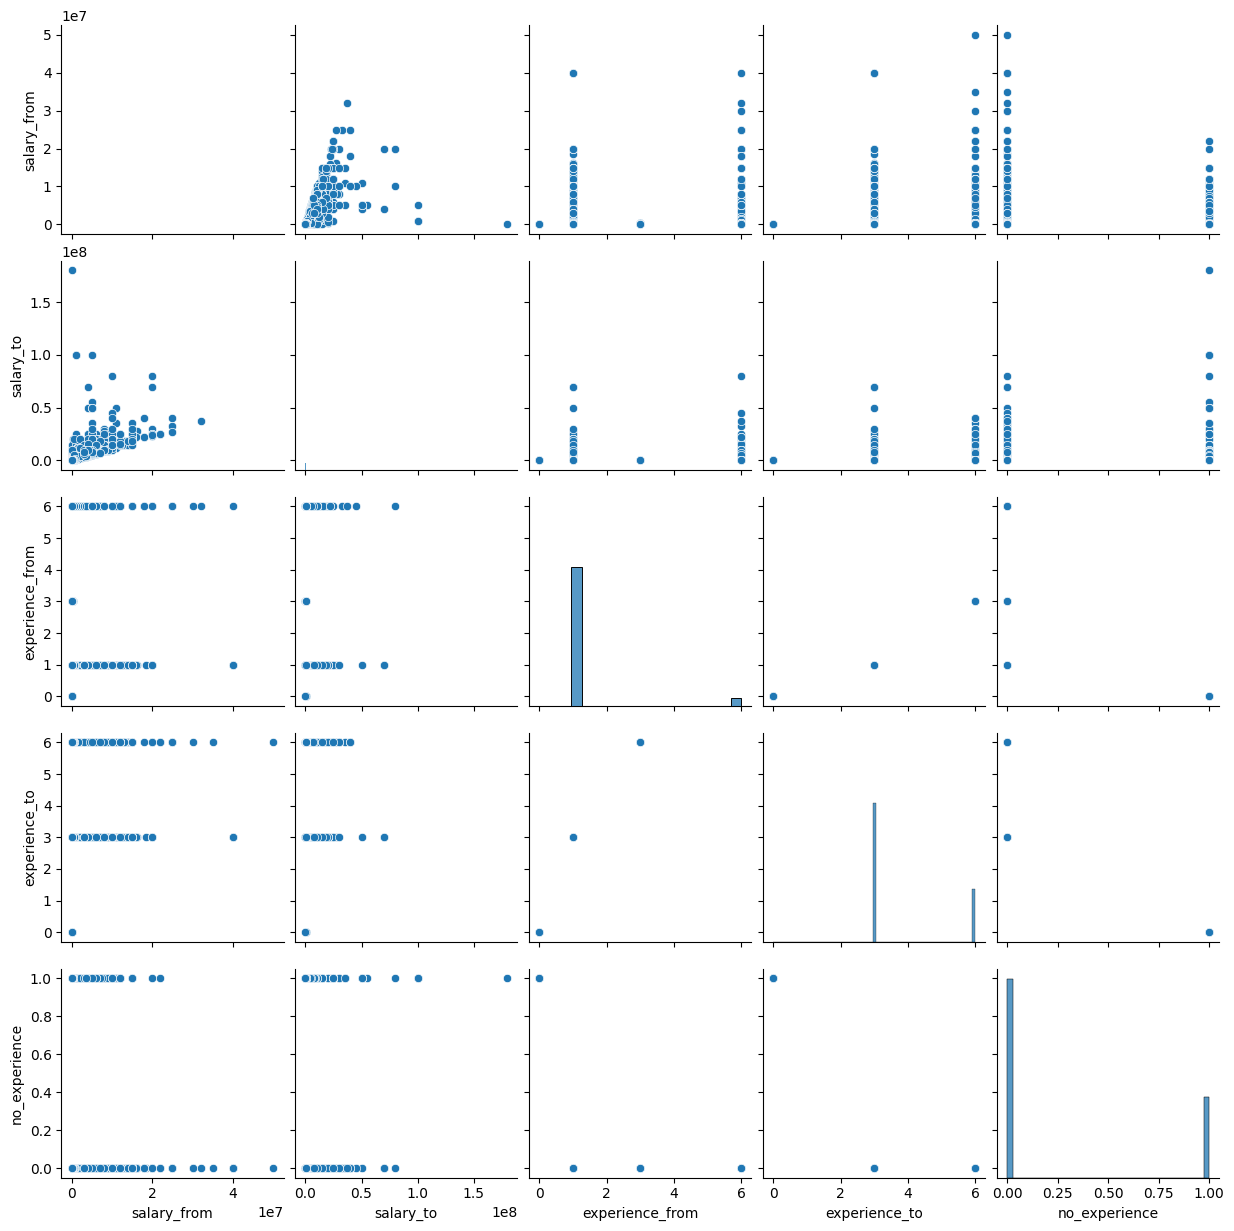

In [148]:
selected_columns = ['salary_from', 'salary_to', 'experience_from', 'experience_to', 'no_experience']
sns.pairplot(data_set_123_clean_salary[selected_columns])
plt.show()

Из приведенного выше графика можно сделать вывод, что нижний порог зарплаты прямо скоррелирован с верхним порогом зарплаты.
У тех, у кого опыт работы насчитывает более 6 лет, бывает более высокая зарплата, чем у тех, у кого опыт работы соствляет более одного года. Однако, наблюдений о более промежуточных вариантах нет. Кроме того, в вакансиях, требующих опыта работы от 6 лет, в основном предлагается такая же зарплата, как в вакансиях, требующих опыта от 1 года.
С максимальным допустимым опытом работы аналогичная связь: в вакансиях, требующих до 6 лет опыта работы, встречаются обещания более высокой зарпалвты, чем в вакансиях, предполагающих не более года опыта работы.
Ожидаемым образом, в вакансиях, не требующих опыта работы, обещания о размере заработной платы, как правило, меньше, чем в вакансиях с требованиями об опыте работы.

Построим графики, чтобы оценить распределение нижнего порога зарплат.

In [149]:
data = (data_set_123_clean_salary['salary_from']).astype(int)

In [150]:
print("=== АНАЛИЗ ДАННЫХ по столбцу salary_from ===")
print(f"Минимум: {data.min():,.0f}")
print(f"Максимум: {data.max():,.0f}")
print(f"Среднее: {data.mean():,.0f}")
print(f"Медиана: {data.median():,.0f}")
print(f"Стандартное отклонение: {data.std():,.0f}")

# Квартили
print(f"Q1 (25%): {data.quantile(0.25):,.0f}")
print(f"Q2 (50%): {data.quantile(0.50):,.0f}")
print(f"Q3 (75%): {data.quantile(0.75):,.0f}")
print(f"Q95 (95%): {data.quantile(0.95):,.0f}")

# Проверка на выбросы
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]
print(f"Выбросы: {len(outliers)} значений ({len(outliers)/len(data)*100:.1f}%)")

=== АНАЛИЗ ДАННЫХ по столбцу salary_from ===
Минимум: 1
Максимум: 50,000,000
Среднее: 103,844
Медиана: 58,798
Стандартное отклонение: 513,788
Q1 (25%): 40,000
Q2 (50%): 58,798
Q3 (75%): 90,000
Q95 (95%): 200,000
Выбросы: 26251 значений (6.8%)


In [151]:
data = data[~data.isin(outliers)]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


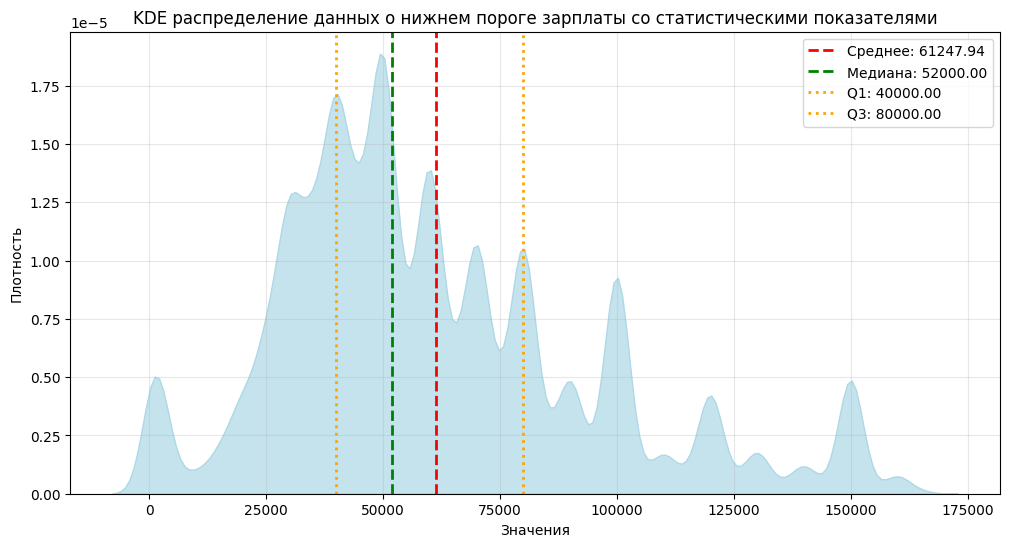

In [152]:
plt.figure(figsize=(12, 6))

# KDE plot вместо histplot
sns.kdeplot(data, fill=True, alpha=0.7, color='lightblue')

# Статистические показатели
stats = {
    'Среднее': data.mean(),
    'Медиана': data.median(),
    'Q1': data.quantile(0.25),
    'Q3': data.quantile(0.75)
}

colors = {'Среднее': 'red', 'Медиана': 'green', 'Q1': 'orange', 'Q3': 'orange'}
linestyles = {'Среднее': '--', 'Медиана': '--', 'Q1': ':', 'Q3': ':'}

for name, value in stats.items():
    plt.axvline(value, color=colors[name], linestyle=linestyles[name], 
                linewidth=2, label=f'{name}: {value:.2f}')

plt.xlabel('Значения')
plt.ylabel('Плотность')
plt.title('KDE распределение данных о нижнем пороге зарплаты со статистическими показателями')
plt.legend()
plt.grid(alpha=0.3)
plt.show()